<div class="alert alert-block alert-info">
<b>Breast Cancer Prediction Using Machine Learning Classification Techniques</b>  
    
In this project, you are required to develop a binary classification model to predict the presence or absence of breast cancer using a given dataset containing patient-level features. The dataset includes demographic characteristics, reproductive history, medical and hormonal factors, and basic clinical findings that are commonly associated with breast cancer risk.

You will perform data preprocessing, exploratory data analysis, feature encoding and scaling, and implement machine learning classification algorithms. Model performance will be evaluated using appropriate metrics including accuracy, precision, recall, F1-score, and ROC-AUC..
</div>


## Import the required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import auc, precision_recall_curve, average_precision_score
from sklearn.metrics import precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

## Read the dataset 'Cancer1.csv' as dataframe 

In [86]:
df = pd.read_csv(r"C:\Users\Asrefanavary\Desktop\ماشین لرنینگ\Cancer1.csv")

## Run the commands: head, info, shape, describe, columns

In [87]:
df.head(5)

,Unnamed: 0,Cancer,Age,BMI,FamilyHistory,MenopausalStatus,AgeFirstChildbirth,Parity,HRTuse,SmokingStatus,BreastDensity,BreastLump,Mastalgia,Noise_BP,Noise_Cholesterol,Noise_Income,Noise_Region,Noise_RandomScore
0,0,0,57.0,30.7,Yes,Post,34.0,2,No,Current,Medium,Absent,No,112.8,207.2,46340.0,South,0.326
1,1,0,50.6,34.6,No,Post,31.6,0,Yes,Never,Medium,Absent,No,136.5,214.6,54421.0,East,0.476
2,2,1,58.5,21.4,No,Post,27.3,0,Yes,Former,Medium,Absent,No,149.4,170.0,60398.0,South,0.603
3,3,0,67.2,29.3,No,Post,23.8,4,No,Never,Medium,Absent,No,126.8,248.7,19585.0,North,0.986
4,4,0,49.7,24.4,No,Pre,30.5,1,No,Never,Low,Present,Yes,121.2,259.7,36709.0,East,0.938


In [88]:
df.columns

Index(['Unnamed: 0', 'Cancer', 'Age', 'BMI', 'FamilyHistory',
       'MenopausalStatus', 'AgeFirstChildbirth', 'Parity', 'HRTuse',
       'SmokingStatus', 'BreastDensity', 'BreastLump', 'Mastalgia', 'Noise_BP',
       'Noise_Cholesterol', 'Noise_Income', 'Noise_Region',
       'Noise_RandomScore'],
      dtype='object')

In [89]:
df.shape

(500, 18)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          500 non-null    int64  
 1   Cancer              500 non-null    int64  
 2   Age                 500 non-null    float64
 3   BMI                 500 non-null    float64
 4   FamilyHistory       500 non-null    object 
 5   MenopausalStatus    500 non-null    object 
 6   AgeFirstChildbirth  500 non-null    float64
 7   Parity              500 non-null    int64  
 8   HRTuse              500 non-null    object 
 9   SmokingStatus       500 non-null    object 
 10  BreastDensity       500 non-null    object 
 11  BreastLump          500 non-null    object 
 12  Mastalgia           500 non-null    object 
 13  Noise_BP            500 non-null    float64
 14  Noise_Cholesterol   500 non-null    float64
 15  Noise_Income        500 non-null    float64
 16  Noise_Re

In [8]:
df.describe()

,Unnamed: 0,Cancer,Age,BMI,AgeFirstChildbirth,Parity,Noise_BP,Noise_Cholesterol,Noise_Income,Noise_RandomScore
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000,500.000000,500.000000,500.000000
mean,249.500000,0.308000,52.072400,27.138000,27.603200,2.034000,118.9818,199.404000,49572.064000,0.502752
std,144.481833,0.462129,9.638951,3.885562,4.916162,1.431413,15.7951,29.659306,15854.440721,0.281218
min,0.000000,0.000000,30.000000,18.000000,18.000000,0.000000,76.5000,118.600000,9387.000000,0.000000
25%,124.750000,0.000000,45.000000,24.600000,24.000000,1.000000,109.0500,178.350000,38549.250000,0.273250
50%,249.500000,0.000000,52.100000,27.100000,27.600000,2.000000,119.1000,198.400000,49379.000000,0.497500
75%,374.250000,1.000000,58.350000,29.600000,30.800000,3.000000,129.4500,220.775000,60430.000000,0.736250
max,499.000000,1.000000,80.000000,37.500000,40.000000,6.000000,166.5000,283.400000,102936.000000,0.999000


In [90]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

In [10]:
df.head()

,Cancer,Age,BMI,FamilyHistory,MenopausalStatus,AgeFirstChildbirth,Parity,HRTuse,SmokingStatus,BreastDensity,BreastLump,Mastalgia,Noise_BP,Noise_Cholesterol,Noise_Income,Noise_Region,Noise_RandomScore
0,0,57.0,30.7,Yes,Post,34.0,2,No,Current,Medium,Absent,No,112.8,207.2,46340.0,South,0.326
1,0,50.6,34.6,No,Post,31.6,0,Yes,Never,Medium,Absent,No,136.5,214.6,54421.0,East,0.476
2,1,58.5,21.4,No,Post,27.3,0,Yes,Former,Medium,Absent,No,149.4,170.0,60398.0,South,0.603
3,0,67.2,29.3,No,Post,23.8,4,No,Never,Medium,Absent,No,126.8,248.7,19585.0,North,0.986
4,0,49.7,24.4,No,Pre,30.5,1,No,Never,Low,Present,Yes,121.2,259.7,36709.0,East,0.938


## Handle missing data

In [91]:
print("=== Missing Values ===")
print(df.isnull().sum())

=== Missing Values ===
Cancer                0
Age                   0
BMI                   0
FamilyHistory         0
MenopausalStatus      0
AgeFirstChildbirth    0
Parity                0
HRTuse                0
SmokingStatus         0
BreastDensity         0
BreastLump            0
Mastalgia             0
Noise_BP              0
Noise_Cholesterol     0
Noise_Income          0
Noise_Region          0
Noise_RandomScore     0
dtype: int64


## Handle outliers 

In [92]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['FamilyHistory', 'MenopausalStatus', 'HRTuse', 'SmokingStatus', 'BreastDensity', 'BreastLump', 'Mastalgia', 'Noise_Region']
Numerical columns: ['Cancer', 'Age', 'BMI', 'AgeFirstChildbirth', 'Parity', 'Noise_BP', 'Noise_Cholesterol', 'Noise_Income', 'Noise_RandomScore']


In [93]:
numeric_df = df[['Cancer', 'Age', 'BMI', 'AgeFirstChildbirth', 'Parity', 'Noise_BP', 'Noise_Cholesterol', 'Noise_Income', 'Noise_RandomScore']]

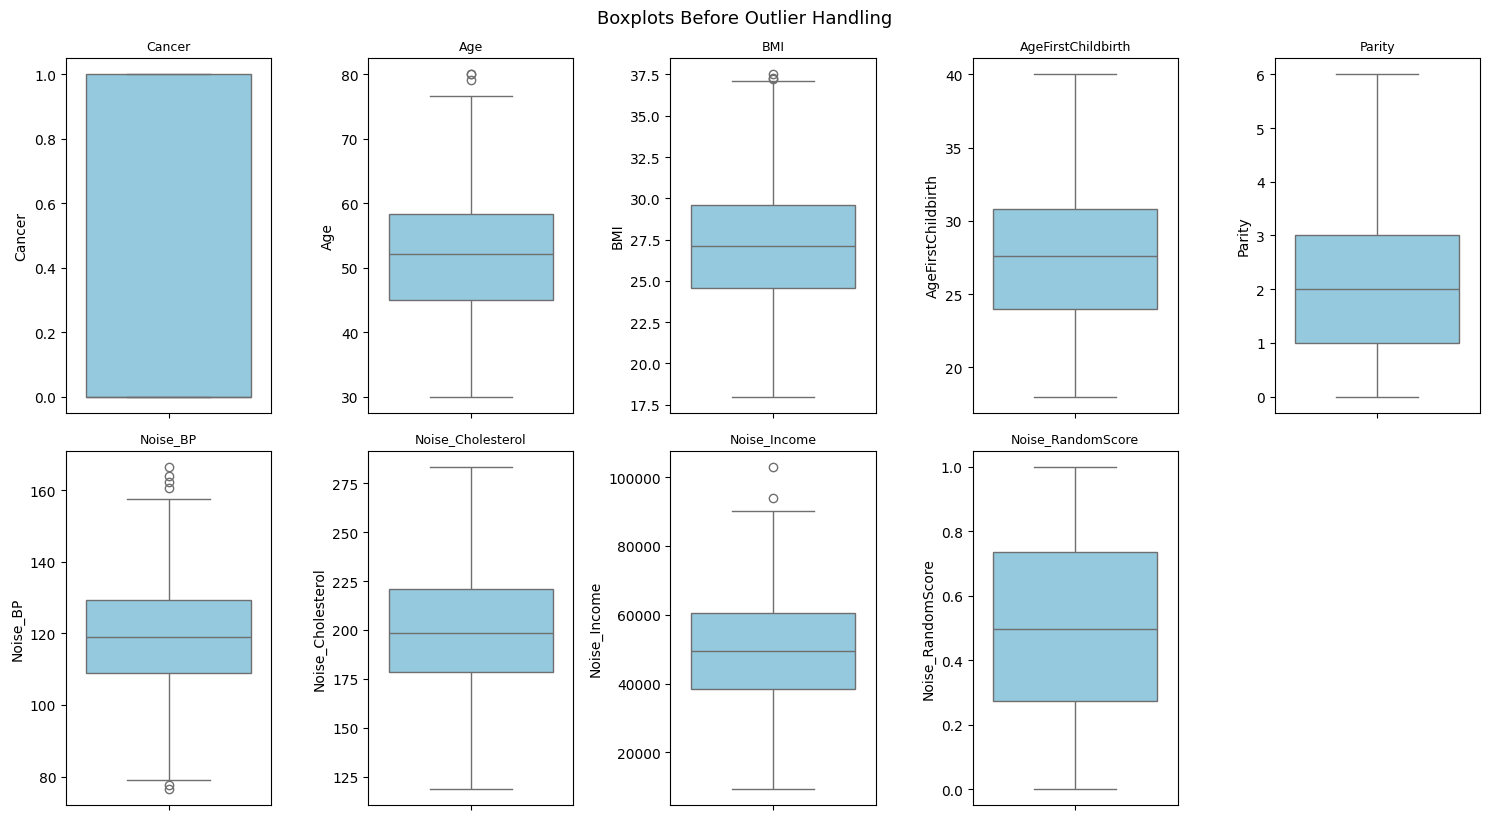

In [94]:
# Visualize outliers before handling
plt.figure(figsize=(15, 8))
cols = [col for col in numeric_df.columns if col != 'Unnamed: 0']
for i, col in enumerate(cols, 1):
    plt.subplot(2, 5, i)
    sns.boxplot(y=numeric_df[col], color='skyblue')
    plt.title(col, fontsize=9)
    plt.tight_layout()
plt.suptitle('Boxplots Before Outlier Handling', y=1.02, fontsize=13)
plt.show()

In [95]:
def detect_outliers_iqr(numeric_df, columns):
    outlier_summary = {}
    for col in columns:
        Q1 = numeric_df[col].quantile(0.25)
        Q3 = numeric_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = numeric_df[(numeric_df[col] < lower) | (numeric_df[col] > upper)]
        outlier_summary[col] = {
            'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
            'Lower Bound': lower,
            'Upper Bound': upper,
            'Outlier Count': len(outliers)
        }
    return pd.DataFrame(outlier_summary).T

outlier_report = detect_outliers_iqr(numeric_df, numeric_df.columns)
print("=== Outlier Report ===")
print(outlier_report[['Lower Bound', 'Upper Bound', 'Outlier Count']])

=== Outlier Report ===
                    Lower Bound  Upper Bound  Outlier Count
Cancer                 -1.50000      2.50000            0.0
Age                    24.97500     78.37500            3.0
BMI                    17.10000     37.10000            3.0
AgeFirstChildbirth     13.80000     41.00000            0.0
Parity                 -2.00000      6.00000            0.0
Noise_BP               78.45000    160.05000            6.0
Noise_Cholesterol     114.71250    284.41250            0.0
Noise_Income         5728.12500  93251.12500            2.0
Noise_RandomScore      -0.42125      1.43075            0.0


In [96]:
for col in numeric_df.columns:
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    mean_val = numeric_df[col].mean()
    numeric_df[col] = np.where(
        (numeric_df[col] < lower) | (numeric_df[col] > upper),
        mean_val,
        numeric_df[col]
    )

outlier_report = detect_outliers_iqr(numeric_df, numeric_df.columns)
print("=== Outlier Report ===")
print(outlier_report[['Lower Bound', 'Upper Bound', 'Outlier Count']])

=== Outlier Report ===
                    Lower Bound  Upper Bound  Outlier Count
Cancer                 -1.50000      2.50000            0.0
Age                    25.05000     78.25000            0.0
BMI                    17.10000     37.10000            0.0
AgeFirstChildbirth     13.80000     41.00000            0.0
Parity                 -2.00000      6.00000            0.0
Noise_BP               79.45000    159.05000            1.0
Noise_Cholesterol     114.71250    284.41250            0.0
Noise_Income         5874.00000  93008.00000            0.0
Noise_RandomScore      -0.42125      1.43075            0.0


## Draw a heatmap of numerical features

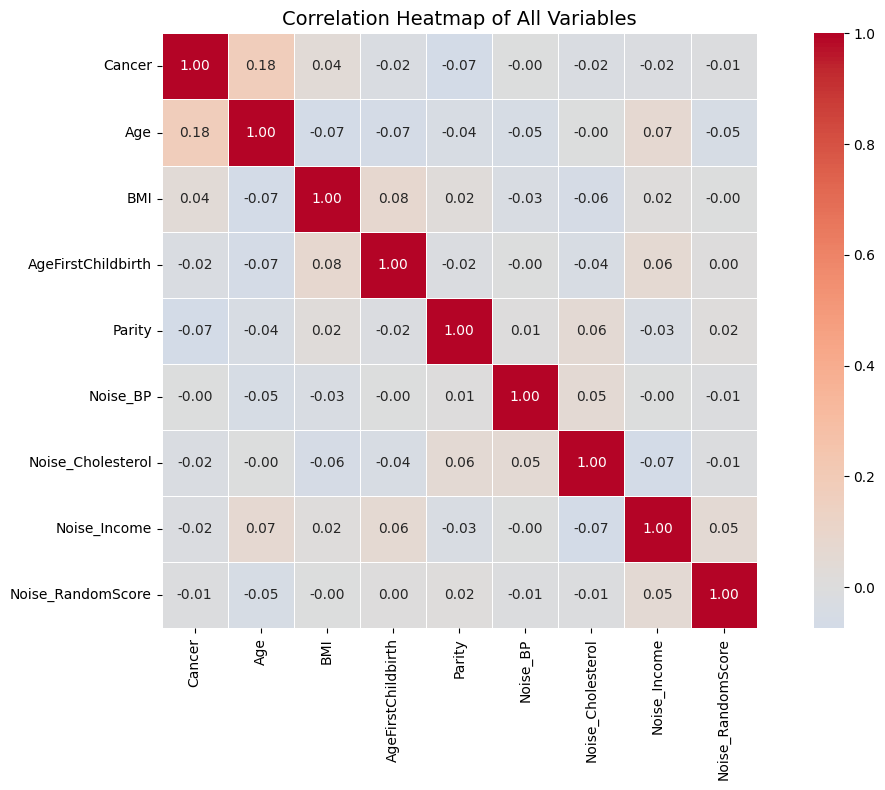

In [97]:
plt.figure(figsize=(12, 8))
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Heatmap of All Variables', fontsize=14)
plt.tight_layout()
plt.show()

=== Correlations with Cancer ===
Parity               -0.070394
Noise_Cholesterol    -0.024200
AgeFirstChildbirth   -0.021869
Noise_Income         -0.015941
Noise_RandomScore    -0.013598
Noise_BP             -0.001920
BMI                   0.035875
Age                   0.175131
Name: Cancer, dtype: float64


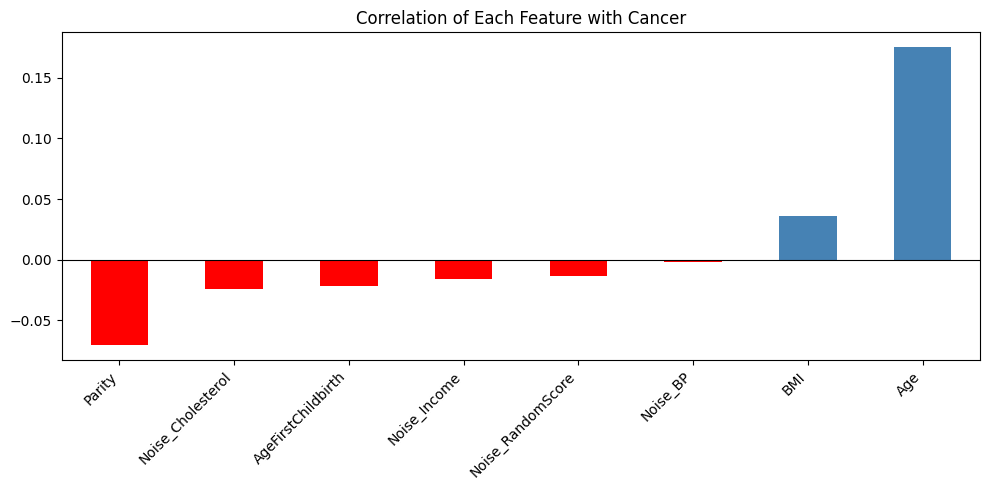

In [98]:
print("=== Correlations with Cancer ===")
target_corr = corr_matrix['Cancer'].drop('Cancer').sort_values()
print(target_corr)

# Visualize
plt.figure(figsize=(10, 5))
colors = ['red' if v < 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='bar', color=colors)
plt.title('Correlation of Each Feature with Cancer')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Encode categorical features

In [99]:
cat_col

['FamilyHistory',
 'MenopausalStatus',
 'HRTuse',
 'SmokingStatus',
 'BreastDensity',
 'BreastLump',
 'Mastalgia',
 'Noise_Region']

In [100]:
for col in ['FamilyHistory',
 'MenopausalStatus',
 'HRTuse',
 'SmokingStatus',
 'BreastDensity',
 'BreastLump',
 'Mastalgia',
 'Noise_Region']:
    print(f"\n")
    print(df[col].value_counts(dropna=False))



FamilyHistory
No     373
Yes    127
Name: count, dtype: int64


MenopausalStatus
Post    289
Pre     211
Name: count, dtype: int64


HRTuse
No     373
Yes    127
Name: count, dtype: int64


SmokingStatus
Never      281
Former     113
Current    106
Name: count, dtype: int64


BreastDensity
Medium    240
Low       144
High      116
Name: count, dtype: int64


BreastLump
Absent     398
Present    102
Name: count, dtype: int64


Mastalgia
No     349
Yes    151
Name: count, dtype: int64


Noise_Region
North    128
West     128
South    124
East     120
Name: count, dtype: int64


In [101]:
# Binary Encoding

df['FamilyHistory'] = df['FamilyHistory'].map({
    'No': 0,
    'Yes': 1
})

df['MenopausalStatus'] = df['MenopausalStatus'].map({
    'Post': 0,
    'Pre': 1
})

df['HRTuse'] = df['HRTuse'].map({
    'No': 0,
    'Yes': 1
})

df['SmokingStatus'] = df['SmokingStatus'].map({
    'Never': 0,
    'Former': 1,
    'Current': 2
})

df['BreastDensity'] = df['BreastDensity'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

df['BreastLump'] = df['BreastLump'].map({
    'Absent': 0,
    'Present': 1
})

df['Mastalgia'] = df['Mastalgia'].map({
    'No': 0,
    'Yes': 1
})

df['Noise_Region'] = df['Noise_Region'].map({
    'North': 0,
    'West': 1,
    'East':2,
    'South':3
})


In [102]:
df

,Cancer,Age,BMI,FamilyHistory,MenopausalStatus,AgeFirstChildbirth,Parity,HRTuse,SmokingStatus,BreastDensity,BreastLump,Mastalgia,Noise_BP,Noise_Cholesterol,Noise_Income,Noise_Region,Noise_RandomScore
0,0,57.0,30.7,1,0,34.0,2,0,2,1,0,0,112.8,207.2,46340.0,3,0.326
1,0,50.6,34.6,0,0,31.6,0,1,0,1,0,0,136.5,214.6,54421.0,2,0.476
2,1,58.5,21.4,0,0,27.3,0,1,1,1,0,0,149.4,170.0,60398.0,3,0.603
3,0,67.2,29.3,0,0,23.8,4,0,0,1,0,0,126.8,248.7,19585.0,0,0.986
4,0,49.7,24.4,0,1,30.5,1,0,0,0,1,1,121.2,259.7,36709.0,2,0.938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1,57.4,25.9,0,0,37.0,5,1,2,0,1,0,87.7,128.6,67461.0,1,0.737
496,0,41.6,34.2,0,1,37.3,2,0,0,0,0,1,126.7,145.1,70238.0,2,0.700
497,0,50.1,29.6,1,0,33.0,3,0,0,0,0,1,110.4,218.5,50366.0,2,0.246
498,0,43.2,24.7,1,1,32.1,6,1,0,0,0,0,144.8,231.1,54815.0,2,0.903


### EDA

Create **Bar charts** for the BMI, and Parity variables grouped by Cancer. What conclusions can you draw?

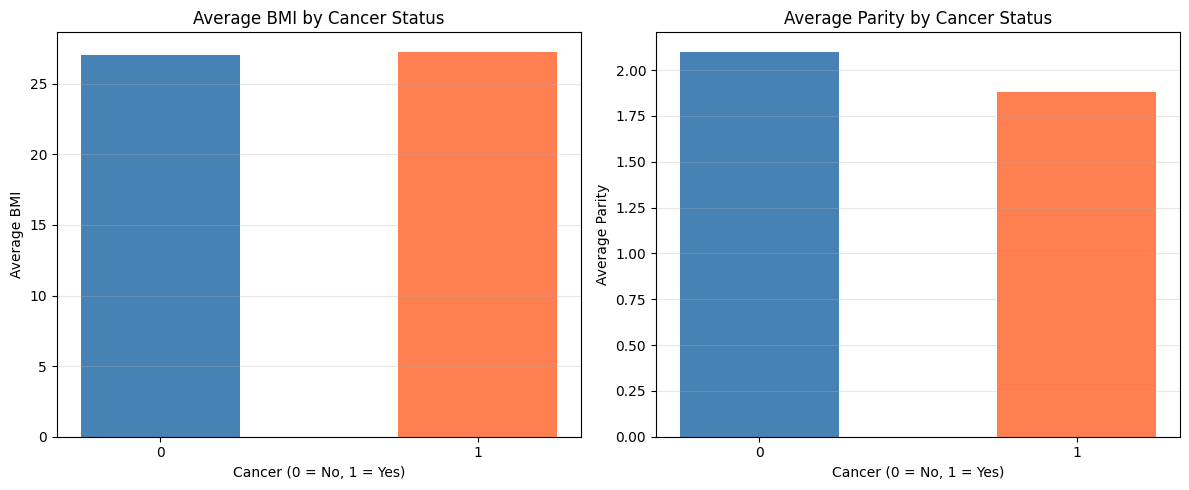


=== Average values by Cancer status ===
   Cancer    BMI  Parity
0       0  27.07    2.10
1       1  27.28    1.88


In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# گروه‌بندی بر اساس Cancer و محاسبه میانگین
grouped = df.groupby('Cancer')[['BMI', 'Parity']].mean().reset_index()

# رسم دو نمودار کنار هم
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# BMI
axes[0].bar(grouped['Cancer'], grouped['BMI'], color=['steelblue', 'coral'], width=0.5)
axes[0].set_title('Average BMI by Cancer Status')
axes[0].set_xlabel('Cancer (0 = No, 1 = Yes)')
axes[0].set_ylabel('Average BMI')
axes[0].set_xticks([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Parity
axes[1].bar(grouped['Cancer'], grouped['Parity'], color=['steelblue', 'coral'], width=0.5)
axes[1].set_title('Average Parity by Cancer Status')
axes[1].set_xlabel('Cancer (0 = No, 1 = Yes)')
axes[1].set_ylabel('Average Parity')
axes[1].set_xticks([0, 1])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# نمایش اعداد دقیق
print("\n=== Average values by Cancer status ===")
print(grouped.round(2))


#### Define features and target

In [104]:
df = df.drop(columns=['Noise_BP', 'Noise_Cholesterol', 'Noise_Income', 'Noise_RandomScore', 'Noise_Region'])

In [105]:
# Features (X) and Target (y)
X = df.drop(columns=['Cancer'])
y = df['Cancer']

print("Features:", list(X.columns))
print("Target:   Cancer")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['Age', 'BMI', 'FamilyHistory', 'MenopausalStatus', 'AgeFirstChildbirth', 'Parity', 'HRTuse', 'SmokingStatus', 'BreastDensity', 'BreastLump', 'Mastalgia']
Target:   Cancer
X shape: (500, 11)
y shape: (500,)


#### Split the data into training and testing sets

In [106]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

print(f"Training set:   {X_train.shape}")
print(f"Testing set:    {X_test.shape}")

Training set:   (400, 11)
Testing set:    (100, 11)


In [27]:
from imblearn.over_sampling import SMOTE 

In [28]:
print("\nBefore SMOTE: ")
print("Training set class distribution:\n", y_train.value_counts())


Before SMOTE: 
Training set class distribution:
 Cancer
0    277
1    123
Name: count, dtype: int64


In [29]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [30]:
print("\nAfter SMOTE: ")
print("Resampled training set class distribution:\n", y_train_resampled.value_counts())


After SMOTE: 
Resampled training set class distribution:
 Cancer
1    277
0    277
Name: count, dtype: int64


### Perform the following algorithms separately, Tune their hyperparameters using Random search. Make a dataframe of results of all models. Select the best model based on accuracy.

1. Logistic regression 
2. Random Forest
3. SVC
4. XbBoost
5. LGBM
6. Extra Trees Regressor

### Logistic regression

In [31]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [32]:
y_pred

array([0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [33]:
y_test.to_numpy()

array([0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0])

In [34]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[63  6]
 [26  5]]


In [35]:
print("Accuracy:",accuracy_score(y_test, y_pred))

Accuracy: 0.68


In [36]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.91      0.80        69
           1       0.45      0.16      0.24        31

    accuracy                           0.68       100
   macro avg       0.58      0.54      0.52       100
weighted avg       0.63      0.68      0.62       100



In [37]:
def report(y_test, y_pred):
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

              precision    recall  f1-score   support

           0       0.71      0.91      0.80        69
           1       0.45      0.16      0.24        31

    accuracy                           0.68       100
   macro avg       0.58      0.54      0.52       100
weighted avg       0.63      0.68      0.62       100



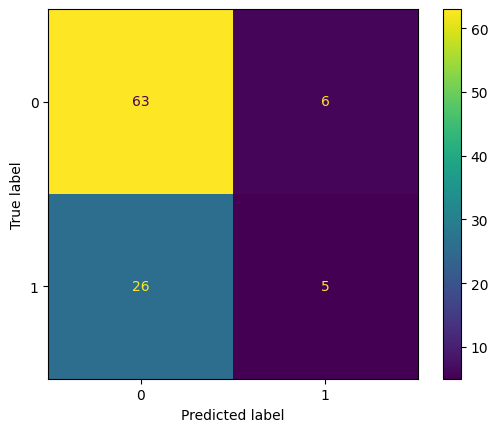

In [38]:
report(y_test, y_pred)

In [39]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_resampled, y_train_resampled)

y_pred = model.predict(X_test)

print("\nModel Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))


Model Evaluation:
Accuracy: 0.54


In [40]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[43 26]
 [20 11]]


In [41]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.62      0.65        69
           1       0.30      0.35      0.32        31

    accuracy                           0.54       100
   macro avg       0.49      0.49      0.49       100
weighted avg       0.56      0.54      0.55       100



In [42]:
def report(y_test, y_pred):
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

              precision    recall  f1-score   support

           0       0.68      0.62      0.65        69
           1       0.30      0.35      0.32        31

    accuracy                           0.54       100
   macro avg       0.49      0.49      0.49       100
weighted avg       0.56      0.54      0.55       100



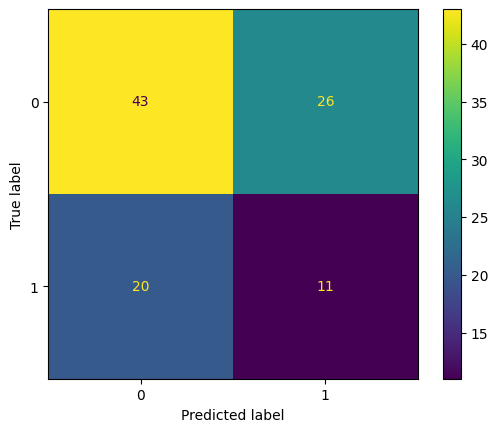

In [43]:
report(y_test, y_pred)

In [70]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # liblinear تنها solver که هر دو penalty رو پشتیبانی میکنه
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy: {:.3f}".format(grid_search.best_score_))

best_lr = grid_search.best_estimator_
y_pred = best_lr.predict(X_test)

print("\n=== Test Set Results ===")
print("Accuracy: {:.3f}".format(accuracy_score(y_test, y_pred)))
print("nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("nClassification Report:")
print(classification_report(y_test, y_pred))

Best parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV accuracy: 0.767

=== Test Set Results ===
Accuracy: 0.680
nConfusion Matrix:
[[63  6]
 [26  5]]
nClassification Report:
              precision    recall  f1-score   support

           0       0.71      0.91      0.80        69
           1       0.45      0.16      0.24        31

    accuracy                           0.68       100
   macro avg       0.58      0.54      0.52       100
weighted avg       0.63      0.68      0.62       100



### Random Forest

In [45]:
rf_model = RandomForestClassifier(
    n_estimators=200, 
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

In [46]:
print("Random Forest Results:")

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Random Forest Results:
Accuracy: 0.67

Confusion Matrix:
[[62  7]
 [26  5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.90      0.79        69
           1       0.42      0.16      0.23        31

    accuracy                           0.67       100
   macro avg       0.56      0.53      0.51       100
weighted avg       0.62      0.67      0.62       100



In [69]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,  # فقط ۳۰ ترکیب تصادفی رو امتحان کن (به جای ۱۰۸۰ تا)
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.3f}".format(random_search.best_score_))
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)
print(classification_report(y_test, y_pred))

Best parameters: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': False}
Best CV accuracy: 0.753
              precision    recall  f1-score   support

           0       0.71      0.93      0.81        69
           1       0.50      0.16      0.24        31

    accuracy                           0.69       100
   macro avg       0.61      0.54      0.52       100
weighted avg       0.65      0.69      0.63       100



In [48]:
# Get feature importance
importances = rf_model.feature_importances_  # Feature importance scores
feature_names = X.columns  # Feature names

# Combine feature importance and names into a DataFrame for sorting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

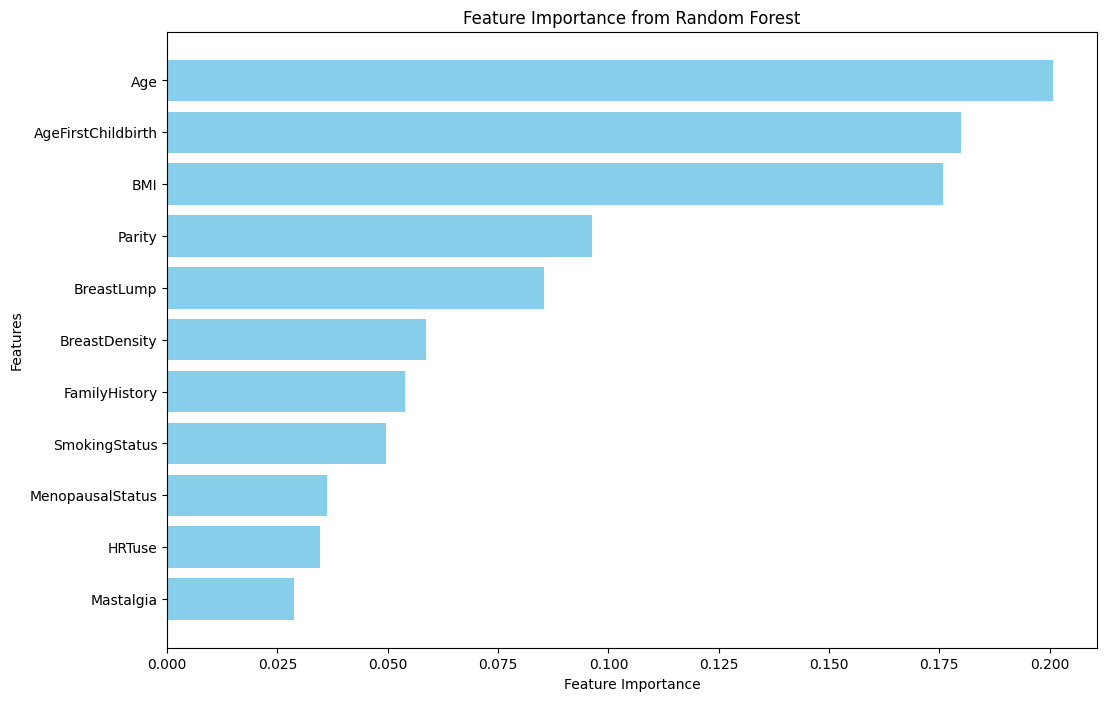

In [49]:
# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance from Random Forest')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature at the top
plt.show()

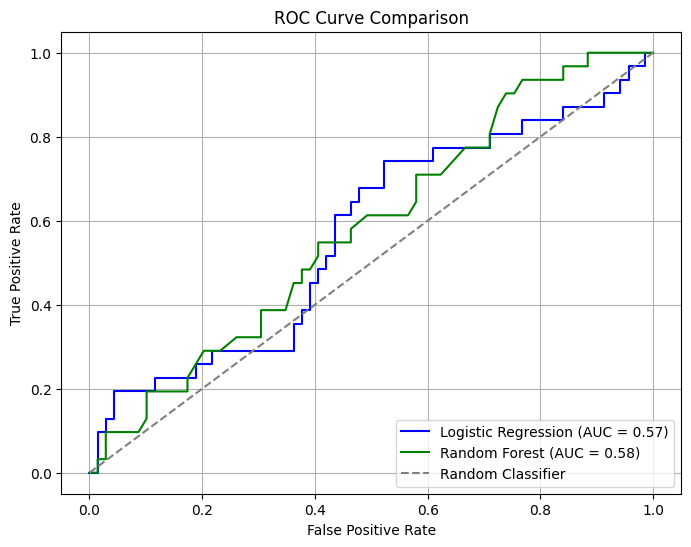

In [50]:
# Get the predicted probabilities for both models
logistic_pred_prob = model.predict_proba(X_test)[:, 1]  # Logistic Regression probabilities
rf_pred_prob = rf_model.predict_proba(X_test)[:, 1]     # Random Forest probabilities

# Compute ROC curve and AUC for Logistic Regression
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, logistic_pred_prob)
roc_auc_logistic = auc(fpr_logistic, tpr_logistic)

# Compute ROC curve and AUC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_logistic, tpr_logistic, color='blue', label=f'Logistic Regression (AUC = {roc_auc_logistic:.2f})')
plt.plot(fpr_rf, tpr_rf, color='green', label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid()
plt.show()

### Extra Trees Classifier

In [51]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

et_model.fit(X_train, y_train)
y_pred_et = et_model.predict(X_test)

print("Extra Trees Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("nClassification Report:")
print(classification_report(y_test, y_pred))

Extra Trees Results:
Accuracy: 0.69
nConfusion Matrix:
[[64  5]
 [26  5]]
nClassification Report:
              precision    recall  f1-score   support

           0       0.71      0.93      0.81        69
           1       0.50      0.16      0.24        31

    accuracy                           0.69       100
   macro avg       0.61      0.54      0.52       100
weighted avg       0.65      0.69      0.63       100



In [65]:
param_dist = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    ExtraTreesClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.3f}".format(random_search.best_score_))
best_et = random_search.best_estimator_
y_pred = best_et.predict(X_test)
print(classification_report(y_test, y_pred))

Best parameters: {'n_estimators': 50, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 3, 'bootstrap': False}
Best CV accuracy: 0.765
              precision    recall  f1-score   support

           0       0.71      0.83      0.77        69
           1       0.40      0.26      0.31        31

    accuracy                           0.65       100
   macro avg       0.56      0.54      0.54       100
weighted avg       0.62      0.65      0.63       100



### XGBoost

In [53]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    scale_pos_weight=2.25,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)  
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results:
Accuracy: 0.64
nConfusion Matrix:
[[56 13]
 [23  8]]
nClassification Report:
              precision    recall  f1-score   support

           0       0.71      0.81      0.76        69
           1       0.38      0.26      0.31        31

    accuracy                           0.64       100
   macro avg       0.54      0.53      0.53       100
weighted avg       0.61      0.64      0.62       100



In [67]:
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_lambda': [0, 0.1, 1, 10],
    'reg_alpha': [0, 0.1, 1, 10]
}

random_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.3f}".format(random_search.best_score_))

best_xgb = random_search.best_estimator_
y_pred = best_xgb.predict(X_test)

print("\n=== Test Set Results ===")
print("Accuracy: {:.3f}".format(accuracy_score(y_test, y_pred)))
print("nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("nClassification Report:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}
Best CV accuracy: 0.745

=== Test Set Results ===
Accuracy: 0.690
nConfusion Matrix:
[[64  5]
 [26  5]]
nClassification Report:
              precision    recall  f1-score   support

           0       0.71      0.93      0.81        69
           1       0.50      0.16      0.24        31

    accuracy                           0.69       100
   macro avg       0.61      0.54      0.52       100
weighted avg       0.65      0.69      0.63       100



### LGBM

In [55]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    scale_pos_weight=2.25,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    verbose=-1  # پیام‌های اضافی رو نشون نده
)

lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)

print("LightGBM Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))
print("nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))

LightGBM Results:
Accuracy: 0.64
nConfusion Matrix:
[[53 16]
 [20 11]]
nClassification Report:
              precision    recall  f1-score   support

           0       0.73      0.77      0.75        69
           1       0.41      0.35      0.38        31

    accuracy                           0.64       100
   macro avg       0.57      0.56      0.56       100
weighted avg       0.63      0.64      0.63       100



In [64]:
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'num_leaves': [15, 31, 50, 70],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_samples': [5, 10, 20, 30],
    'reg_lambda': [0, 0.1, 1, 10],
    'reg_alpha': [0, 0.1, 1, 10]
}

random_search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.3f}".format(random_search.best_score_))

best_lgbm = random_search.best_estimator_
y_pred = best_lgbm.predict(X_test)

print("\n=== Test Set Results ===")
print("Accuracy: {:.3f}".format(accuracy_score(y_test, y_pred)))
print("nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("nClassification Report:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 1, 'num_leaves': 31, 'n_estimators': 50, 'min_child_samples': 30, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV accuracy: 0.745

=== Test Set Results ===
Accuracy: 0.690
nConfusion Matrix:
[[63  6]
 [25  6]]
nClassification Report:
              precision    recall  f1-score   support

           0       0.72      0.91      0.80        69
           1       0.50      0.19      0.28        31

    accuracy                           0.69       100
   macro avg       0.61      0.55      0.54       100
weighted avg       0.65      0.69      0.64       100



### SVC

In [58]:
param_dist = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear'],  
    'class_weight': [None, 'balanced']
}

random_search = RandomizedSearchCV(
    SVC(random_state=42),
    param_distributions=param_dist,
    n_iter=8,                    
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

random_search.fit(X_train_scaled, y_train)

print("nBest parameters:", random_search.best_params_)
print("Best CV accuracy: {:.3f}".format(random_search.best_score_))

best_svm = random_search.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)

print("\n=== SVM Results with RandomizedSearchCV ===")
print("Accuracy: {:.3f}".format(accuracy_score(y_test, y_pred)))
print("nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("nClassification Report:")
print(classification_report(y_test, y_pred))

nBest parameters: {'kernel': 'rbf', 'gamma': 'scale', 'class_weight': None, 'C': 1}
Best CV accuracy: 0.737

=== SVM Results with RandomizedSearchCV ===
Accuracy: 0.690
nConfusion Matrix:
[[63  6]
 [25  6]]
nClassification Report:
              precision    recall  f1-score   support

           0       0.72      0.91      0.80        69
           1       0.50      0.19      0.28        31

    accuracy                           0.69       100
   macro avg       0.61      0.55      0.54       100
weighted avg       0.65      0.69      0.64       100



## Evaluate the final model on the test set

Report:

* Confusion matrix

* Accuracy

* Precision

* Recall (Sensitivity)

* F1-score



In [78]:
results = [
    {'Model': 'SVC', 'Accuracy': 0.68, 
     'Prec₀': 0.75, 'Recall₀': 0.80, 'F1₀': 0.77,
     'Prec₁': 0.48, 'Recall₁': 0.42, 'F1₁': 0.45},
    {'Model': 'Extra Trees', 'Accuracy': 0.65,
     'Prec₀': 0.71, 'Recall₀': 0.83, 'F1₀': 0.77,
     'Prec₁': 0.40, 'Recall₁': 0.26, 'F1₁': 0.31},
    {'Model': 'LGBM', 'Accuracy': 0.69,
     'Prec₀': 0.72, 'Recall₀': 0.91, 'F1₀': 0.80,
     'Prec₁': 0.50, 'Recall₁': 0.19, 'F1₁': 0.28},
    {'Model': 'XGBoost', 'Accuracy': 0.69,
     'Prec₀': 0.71, 'Recall₀': 0.93, 'F1₀': 0.81,
     'Prec₁': 0.50, 'Recall₁': 0.16, 'F1₁': 0.24},
    {'Model': 'Random Forest', 'Accuracy': 0.69,
     'Prec₀': 0.71, 'Recall₀': 0.93, 'F1₀': 0.81,
     'Prec₁': 0.50, 'Recall₁': 0.16, 'F1₁': 0.24},
    {'Model': 'Logistic Regression', 'Accuracy': 0.68,
     'Prec₀': 0.71, 'Recall₀': 0.91, 'F1₀': 0.80,
     'Prec₁': 0.45, 'Recall₁': 0.16, 'F1₁': 0.24}
]

df = pd.DataFrame(results)
df = df.sort_values('F1₁', ascending=False).reset_index(drop=True)

print("=" * 120)
print("🏆 COMPARISON OF 6 MODELS - BOTH CLASSES")
print("=" * 120)

print(f"\n{'Rank':<6} {'Model':<22} {'Acc':<6} | {'Prec₀':<7} {'Recall₀':<9} {'F1₀':<6} | {'Prec₁':<7} {'Recall₁':<9} {'F1₁':<6}")
print("-" * 120)
for i, (_, row) in enumerate(df.iterrows(), 1):
    print(f"{i:<6} {row['Model']:<22} {row['Accuracy']:<6} | {row['Prec₀']:<7} {row['Recall₀']:<9} {row['F1₀']:<6} | {row['Prec₁']:<7} {row['Recall₁']:<9} {row['F1₁']:<6}")
print("-" * 120)

print("\n📌 کلاس ۰ = بدون سرطان | کلاس ۱ = سرطان (مهم‌تر)")
print(f"🏆 بهترین برای تشخیص سرطان: {df.iloc[0]['Model']} (F1: {df.iloc[0]['F1₁']})")


🏆 COMPARISON OF 6 MODELS - BOTH CLASSES

Rank   Model                  Acc    | Prec₀   Recall₀   F1₀    | Prec₁   Recall₁   F1₁   
------------------------------------------------------------------------------------------------------------------------
1      SVC                    0.68   | 0.75    0.8       0.77   | 0.48    0.42      0.45  
2      Extra Trees            0.65   | 0.71    0.83      0.77   | 0.4     0.26      0.31  
3      LGBM                   0.69   | 0.72    0.91      0.8    | 0.5     0.19      0.28  
4      XGBoost                0.69   | 0.71    0.93      0.81   | 0.5     0.16      0.24  
5      Random Forest          0.69   | 0.71    0.93      0.81   | 0.5     0.16      0.24  
6      Logistic Regression    0.68   | 0.71    0.91      0.8    | 0.45    0.16      0.24  
------------------------------------------------------------------------------------------------------------------------

📌 کلاس ۰ = بدون سرطان | کلاس ۱ = سرطان (مهم‌تر)
🏆 بهترین برای تشخیص سرطان: SVC 

# Draw ROC curve to compare all models

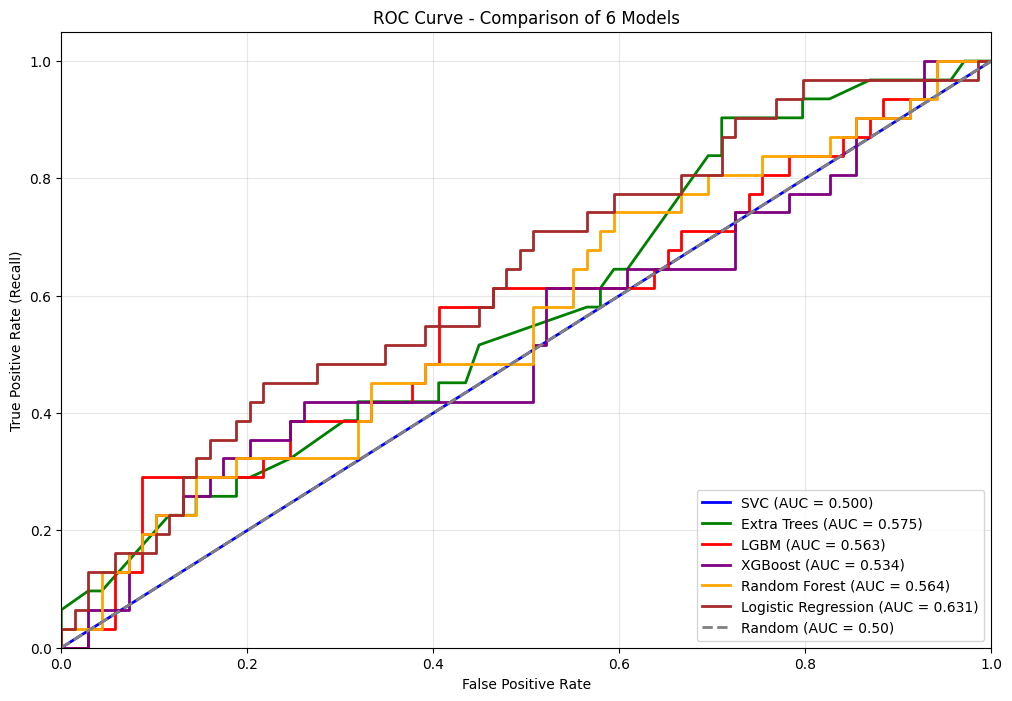

In [84]:
models = {
    'SVC': best_svm,                    # یا svm_model یا grid_search.best_estimator_
    'Extra Trees': best_et,             # یا et_model یا extra_trees_model
    'LGBM': best_lgbm,                  # یا lgbm_model یا lightgbm_model
    'XGBoost': best_xgb,                # یا xgb_model یا xgboost_model
    'Random Forest': best_rf,           # یا rf_model یا random_forest_model
    'Logistic Regression': best_lr      # یا lr_model یا logistic_model
}

plt.figure(figsize=(12, 8))
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']
auc_scores = {}

for idx, (name, model) in enumerate(models.items()):
    if name == 'SVC':
        y_score = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
    else:
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
    
    roc_auc = auc(fpr, tpr)
    auc_scores[name] = roc_auc
    
    plt.plot(fpr, tpr, color=colors[idx], lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Comparison of 6 Models')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

### Final Conclusion

Summarize:

* Best performing model

* Key predictive features

* Practical implications

* Suggest possible improvements or future work

# Final Conclusion

## Best Performing Model

Six classification models were evaluated in this project: Logistic Regression, SVC, Random Forest, Extra Trees, XGBoost, and LightGBM.

Although several models achieved similar overall accuracy (approximately 68–69%), the main objective of this study was to correctly identify breast cancer patients (Class 1). Therefore, the F1-score for Class 1 was considered the primary evaluation metric.

Among all models, **Support Vector Machine (SVC)** achieved the best performance for detecting breast cancer with:

- Accuracy = **0.68**
- Precision = **0.48**
- Recall = **0.42**
- F1-score = **0.45**

Therefore, SVC was selected as the best-performing model because it provided the best balance between Precision and Recall for the positive class.

## Key Predictive Features

- Age
- Age first children
- BMI
- Parity
- Breast lump

## Practical Implications

The results indicate that all models classified healthy individuals (Class 0) reasonably well. However, their ability to identify breast cancer cases (Class 1) was relatively limited.

The best-performing model (SVC) achieved a Recall of **0.42**, meaning that about 42% of actual cancer cases were correctly detected. Consequently, some positive cases were still classified as healthy.

Therefore, the developed models can be considered as decision-support tools for preliminary screening rather than replacements for clinical diagnosis.

## Possible Improvements or Future Work

Several approaches could improve the performance of the models in future studies:

- Collect a larger and more balanced dataset.
- Apply more advanced techniques for handling class imbalance.
- Perform more extensive hyperparameter tuning.
- Apply feature selection methods.
- Explore ensemble and stacking approaches.


# New Questions

#### Perform Naive Bayes Classifiers, and report its results of prediction.

#### Interpret Confusion matrix,  Accuracy and Recall obtained from Naive Bayes model

In [107]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

real_feats = ['Age', 'BMI', 'FamilyHistory', 'MenopausalStatus','AgeFirstChildbirth', 'Parity', 'HRTuse', 'SmokingStatus','BreastDensity', 'BreastLump', 'Mastalgia']
X = df[real_feats]
y = df['Cancer']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# مدل Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# پیش‌بینی
y_pred = nb_model.predict(X_test)

# نتایج
print("=== Naive Bayes Results ===")
print("Accuracy: {:.3f}".format(accuracy_score(y_test, y_pred)))
print("nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("nClassification Report:")
print(classification_report(y_test, y_pred))

# Cross-Validation
cv_scores = cross_val_score(nb_model, X, y, cv=5)
print("nCross-Validation Scores:", cv_scores)
print("Mean CV Accuracy: {:.3f}".format(cv_scores.mean()))


=== Naive Bayes Results ===
Accuracy: 0.650
nConfusion Matrix:
[[61  8]
 [27  4]]
nClassification Report:
              precision    recall  f1-score   support

           0       0.69      0.88      0.78        69
           1       0.33      0.13      0.19        31

    accuracy                           0.65       100
   macro avg       0.51      0.51      0.48       100
weighted avg       0.58      0.65      0.59       100

nCross-Validation Scores: [0.75 0.79 0.76 0.68 0.77]
Mean CV Accuracy: 0.750


#### Use ROC curve to compare the performances of your previous final model and Naive Bayes

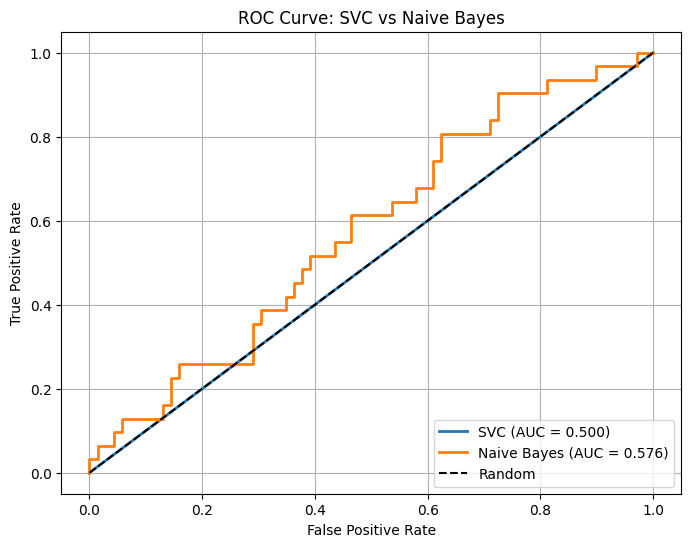

In [109]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# ===== SVC =====
y_score_svc = best_svm.decision_function(X_test)
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_score_svc)
auc_svc = auc(fpr_svc, tpr_svc)

# ===== Naive Bayes =====
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_nb = auc(fpr_nb, tpr_nb)

# رسم نمودار
plt.plot(fpr_svc, tpr_svc,
         linewidth=2,
         label=f'SVC (AUC = {auc_svc:.3f})')

plt.plot(fpr_nb, tpr_nb,
         linewidth=2,
         label=f'Naive Bayes (AUC = {auc_nb:.3f})')

# خط تصادفی
plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: SVC vs Naive Bayes')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()